# 0. SİSTEM KONTROLÜ

Bu hücrede Python, TensorFlow ve OpenCV gibi temel bileşenlerin yüklü olup olmadığını kontrol ediyoruz. Eğitim ve görüntü işleme adımlarına geçmeden önce ortamın hazır olduğundan emin oluyoruz.

In [1]:
# Sistem ve ortam gereksinimlerini kontrol etme adımı
# Gerekli sistem modüllerini içeri aktarıyoruz
import sys, importlib.util

# Kullanılan Python sürümünü ve yolunu kontrol ediyoruz (Uyumluluk için)
print('sys.executable:', sys.executable)
print('python version:', sys.version)

# Görüntü işleme ve derin öğrenme için hayati kütüphanelerin yüklü olup olmadığını test ediyoruz
print('cv2 available in sys.path:', importlib.util.find_spec('cv2') is not None)
print('tensorflow available in sys.path:', importlib.util.find_spec('tensorflow') is not None)


sys.executable: c:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\.venv\Scripts\python.exe
python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
cv2 available in sys.path: False
tensorflow available in sys.path: True


# 1. VERİ SETI YÜKLEME VE HAZIRLANMASI

## Genel Bakış
Bu bölümde malzeme görüntü sınıflandırması için kullanılacak veri setini yükleyeceğiz. **İnternet Veri Setleri** klasöründen 4 farklı malzeme türü (cam, metal, kağıt, plastik) görüntülerini okuyacağız ve modellerin eğitimi için hazırlayacağız.

## Aşamalar:
- 📂 **Veri Yükleme**: PIL (Python Imaging Library) ile görüntüleri oku
- 🔄 **Normalleştirme**: Piksel değerlerini 0-1 arasına dönüştür
- ✂️ **Yeniden Boyutlandırma**: Tüm görüntüleri 128×128 piksel olarak standardize et
- 🎯 **Sınıf Etiketlendirme**: Her malzeme türüne sayısal etiket ata

## 1. Veriyi Yükleme ve İlk İnceleme
Resim verilerini yükleyelim ve sınıf dağılımını inceleyelim.

In [2]:
# Veri işleme, modelleme ve görselleştirme için temel araçları içeri aktarıyoruz
# Klasör okuma işlemleri için os, matris işlemleri için numpy, veri yapıları için pandas kullanıyoruz
import os
import numpy as np
import pandas as pd

# Grafikleri çizdirmek için matplotlib ve seaborn kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ayırma ve performans metrikleri (Confusion Matrix, F1 vb.) için Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

# Derin öğrenme modelini katman katman kurmak için Keras modülleri
from keras import layers, models

# Çıktıda görünecek gereksiz uyarıları gizleyerek temiz bir konsol ekranı sağlıyoruz
import warnings
warnings.filterwarnings('ignore')

# Grafiklerde Türkçe karakter sorunlarını aşmak için varsayılan fontu güncelliyoruz
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
print("Kütüphaneler başarıyla yüklendi!")


Kütüphaneler başarıyla yüklendi!


## 1.1 İlk Veri Çekimi

Bu hücrede veri klasöründeki malzeme görüntülerini sayıyoruz ve her sınıf için örnek sayısını çıkarıyoruz. Böylece veri setinin başlangıç dağılımını görüyoruz.


📂 VERİ SETLERİ BİRLEŞTİRİLİYOR (İnternet + Senin Verin)
Hedef veri klasörü: c:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\verisetleri
✅ GLASS: 529 resim hazır.
✅ METAL: 436 resim hazır.
✅ PAPER: 611 resim hazır.
✅ PLASTIC: 518 resim hazır.

🎯 Toplam 2094 resim birleştirildi!

SINIF DAGILIMI TABLOSU:
  Sinif  Resim Sayisi  Yuzde
  glass           529  25.26
  metal           436  20.82
  paper           611  29.18
plastic           518  24.74


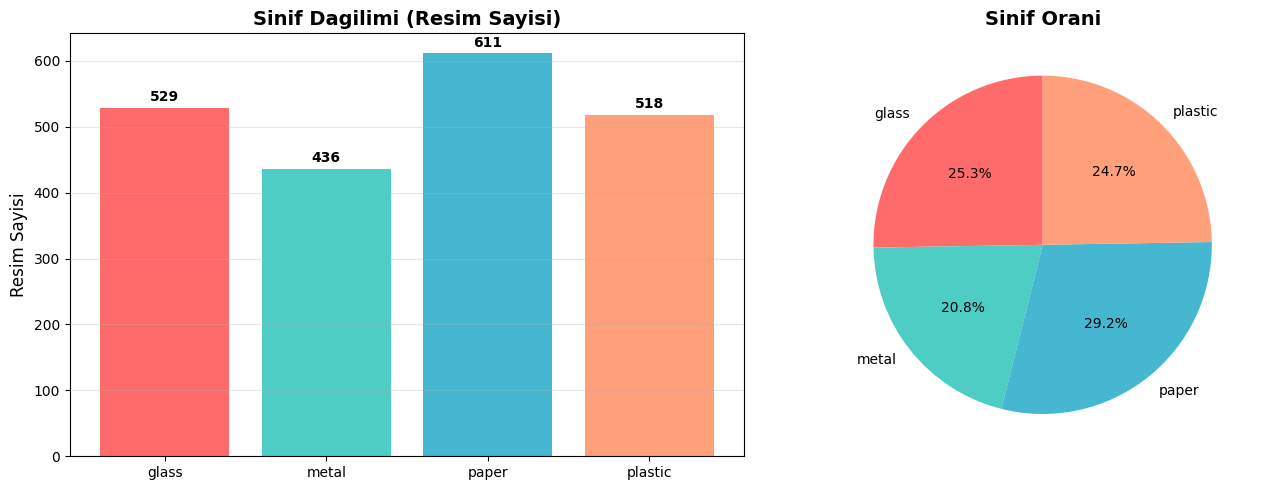

In [3]:
# ========== ADIM 1.5: VERİ SETİ BİLGİSİ ==========
import os
import pandas as pd
import matplotlib.pyplot as plt

print('\n' + '='*70)
print('📂 VERİ SETİ (Sadece BirlesikVeriSeti Klasörü Kullanılıyor)')
print('='*70)

# Kullanıcının 2328 adet resminin olduğu ASIL klasör (Yeniproje'nin bir üst klasörü)
merged_dir = r'C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\BirlesikVeriSeti'

print(f'Hedef veri klasörü: {merged_dir}')

class_names = ['glass', 'metal', 'paper', 'plastic']
class_counts = {}

for class_name in class_names:
    target_class_dir = os.path.join(merged_dir, class_name)
    count = 0
    if os.path.exists(target_class_dir):
        count = len([f for f in os.listdir(target_class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[class_name] = count
    print(f'✅ {class_name.upper()}: {count} resim hazır.')

total_images = sum(class_counts.values())
print(f'\n🎯 Toplam {total_images} resim bulundu!')

# Bu yol, ADIM 1 (Cell 4) için veri yolu olarak kullanılacak
data_path = merged_dir

# --- SINIF DAGILIMI TABLOSU --- 
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Sinif', 'Resim Sayisi'])

if total_images > 0:
    df_classes['Yuzde'] = (df_classes['Resim Sayisi'] / total_images * 100).round(2)
else:
    df_classes['Yuzde'] = 0.0

print('\nSINIF DAGILIMI TABLOSU:')
print(df_classes.to_string(index=False))

if total_images > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    axes[0].bar(df_classes['Sinif'], df_classes['Resim Sayisi'], color=colors)
    axes[0].set_title('Sinif Dagilimi (Resim Sayisi)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Resim Sayisi', fontsize=12)
    axes[0].grid(axis='y', alpha=0.3)

    for i, v in enumerate(df_classes['Resim Sayisi']):
        axes[0].text(i, v + (max(df_classes['Resim Sayisi'])*0.02) if max(df_classes['Resim Sayisi']) > 0 else 1, str(v), ha='center', fontweight='bold')

    axes[1].pie(df_classes['Resim Sayisi'], labels=df_classes['Sinif'], autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title('Sinif Orani', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('\n[UYARI] BirlesikVeriSeti içinde resim bulunamadığı için grafik çizilemiyor!')


In [4]:
# ========== ADIM 1: VERİ SETI YÜKLEME ==========
print("\n" + "="*70)
print("📂 VERİ SETI YÜKLENIYOR")
print("="*70)

# Bu hücreyi bağımsız çalıştırılabilir hale getiriyoruz
from PIL import Image

# Görüntü boyutu tanımlanıyor (tüm görüntüleri bu boyuta dönüştüreceğiz)
IMG_SIZE = 128

# Malzeme sınıflarının klasör isimleri (İnternet Veri Setleri klasöründen)
classes = ['glass', 'metal', 'paper', 'plastic']

# Veriyi ve etiketleri depolamak için listeler
images = []
labels = []
error_count = 0

# Her sınıf için klasörü gezerek görüntüleri yükle
print("\n🔄 Görüntüler okunuyor...")
for label, class_name in enumerate(classes):
    # Klasör yolu (ana veri seti klasörü + sınıf adı)
    class_path = os.path.join(data_path, class_name)
    
    # Klasördeki tüm dosyaları oku
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for image_file in image_files:
        try:
            # PIL ile görüntü aç
            img = Image.open(os.path.join(class_path, image_file))
            
            # RGB formatına dönüştür (bazı görüntüler farklı format olabilir)
            img = img.convert('RGB')
            
            # Görüntüyü 128×128 piksel olarak yeniden boyutlandır
            img = img.resize((IMG_SIZE, IMG_SIZE))
            
            # NumPy array'e dönüştür ve normalleştir (0-1 arasında)
            img_array = np.array(img) / 255.0
            
            # Listeye ekle
            images.append(img_array)
            labels.append(label)  # 0=glass, 1=metal, 2=paper, 3=plastic
            
        except Exception:
            # Hatalı dosyaları atla
            error_count += 1
            continue

# Array'lere dönüştür
X = np.array(images)  # Görüntü verisi (yükseklik, genişlik, renk kanalı)
y = np.array(labels)  # Sınıf etiketleri

print(f"✅ Toplam {len(X)} görüntü yüklendi")
print(f"   - Glass (Cam): {np.sum(y == 0)} görüntü")
print(f"   - Metal: {np.sum(y == 1)} görüntü")
print(f"   - Paper (Kağıt): {np.sum(y == 2)} görüntü")
print(f"   - Plastic (Plastik): {np.sum(y == 3)} görüntü")
print(f"   - Hata sayısı: {error_count}")
print(f"\n📐 Her görüntü boyutu: {X.shape[1:]} (128×128×3 - Yükseklik×Genişlik×RGB)")


📂 VERİ SETI YÜKLENIYOR

🔄 Görüntüler okunuyor...
✅ Toplam 2328 görüntü yüklendi
   - Glass (Cam): 579 görüntü
   - Metal: 504 görüntü
   - Paper (Kağıt): 662 görüntü
   - Plastic (Plastik): 583 görüntü
   - Hata sayısı: 0

📐 Her görüntü boyutu: (128, 128, 3) (128×128×3 - Yükseklik×Genişlik×RGB)


## 1.6 Örnek Görüntü Testi

Bu hücrede tek bir örnek görüntüyü açarak PIL okuma işleminin doğru çalıştığını doğruluyoruz.

In [5]:
# Görüntü okuma mantığının sorunsuz çalıştığını kontrol etmek için test bir resim yüklüyoruz
from PIL import Image
test_path = os.path.join(data_path, 'glass', 'glass_001.jpg')

try:
    # Belirtilen testi resmini açıp boyutlarını kontrol ediyoruz
    pil_img = Image.open(test_path)
    pil_array = np.array(pil_img)
    
    # Test başarılıysa konsola orijinal boyutunu ve çevrilmiş matrisin şeklini basıyoruz
    print(f"PIL Test Başarılı - Orijinal Boyut: {pil_img.size}, Array Boyutu: {pil_array.shape}")
except Exception as e:
    print(f"PIL HATA: {e}")


PIL HATA: [Errno 2] No such file or directory: 'c:\\Users\\Baran\\Desktop\\Bahar Dönemi\\2.Salı\\3.Yapay Zeka Okuryazarlığı 2\\Yeniproje\\BirlesikVeriSeti\\glass\\glass_001.jpg'


## 1.7 Veri Seti Diagnostik Kontrolü

Bu hücrede klasör yapısını ve dosya tiplerini ayrıntılı biçimde kontrol ediyoruz. Hatalı veya beklenmeyen dosyaları erken yakalamak için kullanılıyor.

In [6]:
# Veri seti bütünlüğünü ve klasör yapısını detaylı bir şekilde test etmek için tanısal (diagnostik) kontrolleri başlatıyoruz
# Bu aşama, bozuk uzantılı dosyaların sisteme dahil edilmesini engelleyerek modelin çökmesini baştan önler
print("DIAGNOSTIK: Veri Seti Kontrol\n")

# Analiz edeceğimiz 4 temel sınıf klasörünün üzerinde teker teker geziniyoruz
for class_name in classes:
    # Hem ana dizin yolunu hem de sınıf ismini birleştirerek o sınıfın işletim sistemindeki mutlak yolunu (absolute path) oluşturuyoruz
    class_path = os.path.join(data_path, class_name)
    
    # Sistemin gerçekten bu klasöre ulaşıp ulaşamadığını os.path.exists() fonksiyonu ile doğruluyoruz
    if os.path.exists(class_path):
        # Klasör içerisindeki gizli veya açık olan bütün dosyaları (resim, txt, log vs.) bir liste halinde çekiyoruz
        all_files = os.listdir(class_path)
        
        # Dosya listesini döngüyle tarayarak, yapay zeka modelimizin sadece görüntü işleme kapasitesine uygun olanları seçiyoruz
        # '.lower()' komutu .JPG, .JpEg gibi büyük/küçük harf karmaşalarından doğacak atlamaları engeller
        image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Filtreleme sonucunda sistemdeki ham dosya sayısını ve gerçek işlenebilir resim dosyasını konsola basıp karşılaştırıyoruz
        print(f"[{class_name}] Toplam Dosya: {len(all_files)} | Resim Dosyası: {len(image_files)}")


DIAGNOSTIK: Veri Seti Kontrol

[glass] Toplam Dosya: 579 | Resim Dosyası: 579
[metal] Toplam Dosya: 504 | Resim Dosyası: 504
[paper] Toplam Dosya: 662 | Resim Dosyası: 662
[plastic] Toplam Dosya: 583 | Resim Dosyası: 583


## 2. Veri Bölüştürme (Train/Test Split)

Veri seti %80 eğitim, %20 test olarak ayrılıyor. `stratify=y` parametresi her sınıfın oranını her iki sette de eşit tutar.

In [7]:
# ========== ADIM 2: VERİ BÖLÜŞTÜRME ==========
print("\n" + "="*70)
print("✂️ VERİ BÖLÜŞTÜRÜLÜYOR (Train/Test Split)")
print("="*70)

# Veriyi %80 eğitim ve %20 test setine ayır
# stratify=y parametresi her sınıfın oranını her iki sette de aynı tutması için kullanılır
# random_state=42 her çalıştırmada aynı sonuç alabilmemiz için sabit seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # %20 test verisi
    random_state=42,      # Sabit seed (tekrarlanabilir sonuçlar)
    stratify=y           # Her sınıfın oranını koru
)

print(f"\n📊 Veri Bölüştürme Sonuçları:")
print(f"   • Eğitim Seti: {len(X_train)} görüntü (%80)")
print(f"   • Test Seti: {len(X_test)} görüntü (%20)")
print(f"\n   Eğitim Setinde Sınıf Dağılımı:")
for i, class_name in enumerate(classes):
    count = np.sum(y_train == i)
    print(f"      - {class_name.upper():10} : {count} görüntü")
print(f"\n   Test Setinde Sınıf Dağılımı:")
for i, class_name in enumerate(classes):
    count = np.sum(y_test == i)
    print(f"      - {class_name.upper():10} : {count} görüntü")


✂️ VERİ BÖLÜŞTÜRÜLÜYOR (Train/Test Split)

📊 Veri Bölüştürme Sonuçları:
   • Eğitim Seti: 1862 görüntü (%80)
   • Test Seti: 466 görüntü (%20)

   Eğitim Setinde Sınıf Dağılımı:
      - GLASS      : 463 görüntü
      - METAL      : 403 görüntü
      - PAPER      : 530 görüntü
      - PLASTIC    : 466 görüntü

   Test Setinde Sınıf Dağılımı:
      - GLASS      : 116 görüntü
      - METAL      : 101 görüntü
      - PAPER      : 132 görüntü
      - PLASTIC    : 117 görüntü


# 3. İTHALAT VE HAZIRLIK

## Gerekli Kütüphaneler
Bu hücrede aşağıdaki 4 model için gerekli tüm kütüphaneler ve ayarlar hazırlanmaktadır:

### Transfer Learning Modelleri
- **Keras Applications**: ResNet50, VGG16, MobileNetV2 (ImageNet ile önceden eğitilmiş ağırlıklar)

### Diğer Araçlar
- 📚 **Callbacks**: EarlyStopping, ReduceLROnPlateau (eğitimi optimize et)
- 🎲 **Data Augmentation**: ImageDataGenerator (veri çeşitliliği sağla)
- 📊 **Optimizer**: Adam (uyarlanabilir öğrenme hızı)

## 2.1 Kütüphane ve Hiperparametre Hazırlığı
Bu hücrede transfer learning modelleri, veri artırma ve eğitim ayarları hazırlanıyor. ResNet50, VGG16 ve MobileNetV2 için ortak eğitim altyapısını kuruyoruz.

In [8]:
# ========== ADIM 3: GEREKLI KÜTÜPHANELERİN İTHALATI ==========
print("\n" + "="*70)
print("📚 KÜTÜPHANELER VE MODELLER HAZIRLANIYORSA")
print("="*70)

# Transfer Learning modellerini Keras Applications'tan ithal et
# TensorFlow'un tf.keras yolunu kullanıyoruz; bu ortamda runtime uyumluluğu daha yüksek
import tensorflow as tf
from keras.applications import ResNet50, VGG16, MobileNetV2
from keras.optimizers import Adam
import time

ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator  # pyright: ignore[reportAttributeAccessIssue]
EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau

print("\n✅ Kütüphaneler ithal edildi")

# ========== HIPERPARAMETRELER ==========
# Bu parametreler tüm modellerin eğitimi için kullanılacak
BATCH_SIZE = 32      # Her seferde kaç görüntü işlenecek (bellek vs hız dengesi)
EPOCHS = 15          # Başlık eğitimi için maksimum epoch sayısı

print(f"\n⚙️  Hiperparametreler:")
print(f"   • Batch Size: {BATCH_SIZE} görüntü/batch")
print(f"   • Başlık Eğitimi: maksimum {EPOCHS} epoch")
print(f"   • Fine-tuning: maksimum 10 epoch")

# ========== VERİ ARTIRMASI (DATA AUGMENTATION) ==========
# Eğitim verisine çeşitli dönüşümler uygulayarak veri çeşitliliğini artır
# Bu overfitting'i azaltmaya yardımcı olur
print("\n🔄 Veri Artırma (Data Augmentation) Ayarlanıyor:")

train_datagen = ImageDataGenerator(
    rotation_range=10,           # ±10 derece döndürme
    width_shift_range=0.05,      # Yatay olarak %5 kaydırma
    height_shift_range=0.05,     # Dikey olarak %5 kaydırma
    zoom_range=0.05,             # %5 yakınlaştırma/uzaklaştırma
    horizontal_flip=True,        # Yatay çevirme (bazı malzemeler simetriktir)
    fill_mode='nearest'          # Boş alanları yakın piksellerle doldur
)

print("   ✓ Döndürme: ±10°")
print("   ✓ Kaydırma: %5 yatay ve dikey")
print("   ✓ Yakınlaştırma: %5")
print("   ✓ Yatay Çevirme: Aktif")

# ========== SONUÇ DEPOLARINI HAZIRLA ==========
# Her model için sonuçları depolamak için dictionary'ler
models_dict = {}          # Eğitilmiş modelleri sakla
histories_dict = {}       # Eğitim geçmişini sakla (loss, accuracy vb.)
metrics_dict = {}         # Metrikleri sakla (accuracy, F1, etc.)

print("\n✅ Tüm Hazırlıklar Tamamlandı - 4 Model Eğitimi Başlıyor...")


📚 KÜTÜPHANELER VE MODELLER HAZIRLANIYORSA

✅ Kütüphaneler ithal edildi

⚙️  Hiperparametreler:
   • Batch Size: 32 görüntü/batch
   • Başlık Eğitimi: maksimum 15 epoch
   • Fine-tuning: maksimum 10 epoch

🔄 Veri Artırma (Data Augmentation) Ayarlanıyor:
   ✓ Döndürme: ±10°
   ✓ Kaydırma: %5 yatay ve dikey
   ✓ Yakınlaştırma: %5
   ✓ Yatay Çevirme: Aktif

✅ Tüm Hazırlıklar Tamamlandı - 4 Model Eğitimi Başlıyor...


## MODEL 1: ResNet50

Bu hücrede ResNet50 modeli eğitilmektedir.

In [9]:
# ========== MODEL 1: ResNet50 ==========
print("\n" + "="*70)
print("MODEL 1: ResNet50 - TRANSFER LEARNING")
print("="*70)

# ===== ADIM 1: TEMEL MODELI YÜKLE =====
print("\n🔨 ResNet50 modeli kurulmakta...")
print("   • ImageNet ile önceden eğitilmiş ağırlıklar yükleniyor...")

# ResNet50 temel modelini yükle (ImageNet ağırlıklarıyla)
# include_top=False: Başlık olmadan yükle (sınıflandırma katmanları olmadan)
resnet_base = ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Başlangıçta temel modelinin katmanlarını dondur
# Bu, ImageNet'ten öğrendikleri ağırlıkları koruması anlamına gelir
resnet_base.trainable = False

# ===== ADIM 2: ÖZELLEŞTİRİLMİŞ BAŞLIK EKLE =====
print("   • Özelleştirilmiş başlık ekleniyor...")

# DÜZELTME: ResNet50 modeli ImageNet resimlerini BGR formatında ve özel bir ölçekte bekler.
# Biz resimleri 0-1 aralığında RGB olarak verdiğimiz için model çöküp her şeye '0' tahmin ediyordu.
# Bu Lambda katmanı veriyi ResNet50'nin anlayacağı formata çeviriyor.
model_resnet = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)),
    resnet_base,  # Önceden eğitilmiş ResNet50 temel modeli
    layers.GlobalAveragePooling2D(),  # Uzamsal boyutları ortalama alarak kapat
    layers.Dense(256, activation='relu'),  # Gizli katman 1: 256 nöron
    layers.Dropout(0.5),  # %50 dropout - overfitting'i önle
    layers.Dense(128, activation='relu'),  # Gizli katman 2: 128 nöron
    layers.Dropout(0.3),  # %30 dropout - hafif regulizasyon
    layers.Dense(4, activation='softmax')  # Çıkış katmanı: 4 sınıf
])

# Modeli derle (eğitim için konfigüre et)
model_resnet.compile(
    optimizer='adam',  # Adam optimizeri (adaptif öğrenme hızı)
    loss='sparse_categorical_crossentropy',  # Çok sınıflı sınıflandırma kaybı
    metrics=['accuracy']  # Metrik: doğruluk
)

print(f"✅ ResNet50 hazırlandı | Parametreler: {model_resnet.count_params():,}")

# ===== ADIM 3: BAŞLIK EĞİTİMİ (FROZEN BASE) =====
print("\n🚀 ResNet50 eğitimi başlanıyor...")
print("   • Faz 1: Temel model dondurulmuş, başlık eğitiliyor...")

# Eğitim başlama zamanı (hız hesaplamak için)
start_time_resnet = time.time()

# Modeli eğit
history_resnet = model_resnet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),  # Veri artırması ile eğit
    epochs=15,  # Maksimum 15 epoch
    steps_per_epoch=max(1, len(X_train) // 32),  # Batch sayısı
    validation_data=(X_test, y_test),  # Test verisi ile doğrula
    callbacks=[
        # Eğitimi erken durdur (validation loss artmaya başlarsa)
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        # Öğrenme hızını azalt (loss iyileşmezse)
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

print(f"\n✅ ResNet50 başlık eğitimi tamamlandı!")

# ===== ADIM 4: FINE-TUNING (KISMKACI AÇILMASI) =====
print("\n🔄 ResNet50 fine-tuning başlanıyor...")
print("   • Faz 2: Son 10 katman açılıyor, tüm model eğitiliyor...")

# Temel modelin son katmanlarını aç (öğrenilecek şekilde)
resnet_base.trainable = True

# Ancak ilk 170 katmanı dondur (çok temel özellikler)
for layer in resnet_base.layers[:-10]:
    layer.trainable = False

# Çok düşük öğrenme hızıyla derle (parametreleri ince ayarla)
model_resnet.compile(
    optimizer=Adam(learning_rate=0.00001),  # Çok düşük LR (%0.001'in 1/100'ü)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning eğitimi
history_resnet_ft = model_resnet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10,  # 10 epoch fine-tuning
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)
    ],
    verbose=1
)

# Eğitim süresini hesapla
resnet_time = time.time() - start_time_resnet
print(f"✅ ResNet50 fine-tuning tamamlandı! ({resnet_time:.1f}s)")


MODEL 1: ResNet50 - TRANSFER LEARNING

🔨 ResNet50 modeli kurulmakta...
   • ImageNet ile önceden eğitilmiş ağırlıklar yükleniyor...
   • Özelleştirilmiş başlık ekleniyor...

✅ ResNet50 hazırlandı | Parametreler: 24,145,668

🚀 ResNet50 eğitimi başlanıyor...
   • Faz 1: Temel model dondurulmuş, başlık eğitiliyor...
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.5552 - loss: 1.1967 - val_accuracy: 0.7682 - val_loss: 0.6106 - learning_rate: 0.0010
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4375 - loss: 1.2221 - val_accuracy: 0.7639 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.7208 - loss: 0.7058 - val_accuracy: 0.7876 - val_loss: 0.5561 - learning_rate: 0.0010
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8438 - loss: 0.4340 - val_accuracy: 0.7811 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.7858 - lo

## MODEL 2: VGG16

Bu hücrede VGG16 transfer learning modeli eğitilmektedir. VGG16, 16 katmanlı derin bir konvolüsyonel ağdır ve ImageNet ağırlıklarıyla başlatılır. İlk aşamada başlık katmanları, ardından fine-tuning ile son katmanlar eğitilir.

In [10]:
# ========== MODEL 2: VGG16 ==========
print("\n" + "="*70)
print("MODEL 2: VGG16 - TRANSFER LEARNING")
print("="*70)

# ===== ADIM 1: TEMEL MODELI YÜKLE =====
print("\n🔨 VGG16 modeli kurulmakta...")
print("   • ImageNet ile önceden eğitilmiş ağırlıklar yükleniyor...")

# VGG16 temel modelini yükle
# VGG16: 16 konvolüsyonel katman + 3 tam bağlı katman (daha basit ResNet50'den)
vgg_base = VGG16(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Temel model katmanlarını dondur (ImageNet ağırlıkları korunacak)
vgg_base.trainable = False

# ===== ADIM 2: ÖZELLEŞTİRİLMİŞ BAŞLIK EKLE =====
print("   • Özelleştirilmiş başlık ekleniyor...")

# DÜZELTME: VGG16 da aynı şekilde özel bir önişleme (preprocessing) bekler.
model_vgg = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.vgg16.preprocess_input(x * 255.0)),
    vgg_base,  # VGG16 temel modeli
    layers.GlobalAveragePooling2D(),  # Spatial pooling
    layers.Dense(256, activation='relu'),  # Gizli katman: 256 nöron
    layers.Dropout(0.5),  # %50 dropout
    layers.Dense(128, activation='relu'),  # Gizli katman: 128 nöron
    layers.Dropout(0.3),  # %30 dropout
    layers.Dense(4, activation='softmax')  # 4 sınıf çıkışı
])

# Modeli derle
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ VGG16 hazırlandı | Parametreler: {model_vgg.count_params():,}")

# ===== ADIM 3: BAŞLIK EĞİTİMİ =====
print("\n🚀 VGG16 eğitimi başlanıyor...")
print("   • Faz 1: Temel model dondurulmuş, başlık eğitiliyor...")

start_time_vgg = time.time()

history_vgg = model_vgg.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=15,
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

print(f"\n✅ VGG16 başlık eğitimi tamamlandı!")

# ===== ADIM 4: FINE-TUNING =====
print("\n🔄 VGG16 fine-tuning başlanıyor...")
print("   • Faz 2: Son katmanlar açılıyor, tüm model eğitiliyor...")

vgg_base.trainable = True

# Son 10 katman hariç dondur
for layer in vgg_base.layers[:-10]:
    layer.trainable = False

# Çok düşük LR ile derle
model_vgg.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_ft = model_vgg.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10,
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)
    ],
    verbose=1
)

vgg_time = time.time() - start_time_vgg
print(f"✅ VGG16 fine-tuning tamamlandı! ({vgg_time:.1f}s)")


MODEL 2: VGG16 - TRANSFER LEARNING

🔨 VGG16 modeli kurulmakta...
   • ImageNet ile önceden eğitilmiş ağırlıklar yükleniyor...
   • Özelleştirilmiş başlık ekleniyor...
✅ VGG16 hazırlandı | Parametreler: 14,879,428

🚀 VGG16 eğitimi başlanıyor...
   • Faz 1: Temel model dondurulmuş, başlık eğitiliyor...
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 410ms/step - accuracy: 0.4694 - loss: 2.6528 - val_accuracy: 0.6395 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.5625 - loss: 1.7294 - val_accuracy: 0.6309 - val_loss: 0.9399 - learning_rate: 0.0010
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 440ms/step - accuracy: 0.6038 - loss: 1.2357 - val_accuracy: 0.6931 - val_loss: 0.7642 - learning_rate: 0.0010
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.5000 - loss: 1.4377 - val_accuracy: 0.6974 - val_loss: 0.7582 - learning_rate: 0.0010
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 453ms/step - accuracy: 0.6645 - loss: 0.9372 - 

## MODEL 3: Simple CNN

Bu hücrede sıfırdan tasarlanan Simple CNN (Basit Evrişimli Sinir Ağı) eğitilmektedir. Transfer learning kullanılmaz; tüm ağırlıklar baştan öğrenilir. 3 konvolüsyon bloğu ve Dropout katmanı ile overfitting önlenir.

In [11]:
# ========== MODEL 3: Simple CNN ==========
print("\n" + "="*70)
print("MODEL 3: SIMPLE CNN - SIFIRDAN EGITIM")
print("="*70)

# ===== ADIM 1: MODELI INSA ET =====
print("\n Basit CNN modeli kuruluyor...")
print("   * Sifirdan 3 konvolusyonel blok...")

# Modeli Sequential API ile kuruyoruz.
# NOT: Onceki versiyonda BatchNormalization kullaniyorduk, bu kucuk veri setlerinde
#      modelin tek bir sinifa ezber yapmasi (class collapse) sorununa yol aciyordu.
#      Simdi daha sade ve kararli bir mimari kullaniyoruz.
model_cnn = models.Sequential([
    # --- BLOK 1: Temel kenar ve doku tespiti ---
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # 32 filtre, 3x3 kernel, ReLU aktivasyon, 'same' padding (boyut korunur)
    layers.MaxPooling2D((2, 2)),  # 128x128 -> 64x64

    # --- BLOK 2: Orta seviye ozellik tespiti ---
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # 64 filtre ile daha zengin ozellik haritalari ogreniyoruz
    layers.MaxPooling2D((2, 2)),  # 64x64 -> 32x32

    # --- BLOK 3: Yuksek seviye soyut ozellikler ---
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    # 128 filtre ile malzeme tipine ozgu ozellikler ogreniyoruz
    layers.MaxPooling2D((2, 2)),  # 32x32 -> 16x16

    # --- SINIFLANDIRMA BASLIGI ---
    layers.Flatten(),              # 16x16x128 -> duz vektor
    layers.Dense(128, activation='relu'),    # 128 noronlu tam bagli katman
    layers.Dropout(0.5),           # %50 dropout: ezberlemeyi onler
    layers.Dense(4, activation='softmax')    # 4 sinif cikisi (glass/metal/paper/plastic)
])

# Modeli derle
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Simple CNN hazir | Parametreler: {model_cnn.count_params():,}")

# ===== ADIM 2: EGITIM =====
print("\nSimple CNN egitimi basliyor...")
print("   * Tum katmanlar sifirdan egitiliyor (transfer learning yok)")
print("   * 20 epoch (transfer learning olmadigi icin daha fazla epoch gerekiyor)")

start_time_cnn = time.time()

# Veri artirmali egitim - overfitting'i azaltmak icin
history_cnn = model_cnn.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=20,
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[
        # Validation loss artarsa egitimi erken durdur
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        # Ogrenme hizini otomatik azalt
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

cnn_time = time.time() - start_time_cnn
print(f"\nSimple CNN egitimi tamamlandi! ({cnn_time:.1f}s)")



MODEL 3: SIMPLE CNN - SIFIRDAN EGITIM

 Basit CNN modeli kuruluyor...
   * Sifirdan 3 konvolusyonel blok...
Simple CNN hazir | Parametreler: 4,288,196

Simple CNN egitimi basliyor...
   * Tum katmanlar sifirdan egitiliyor (transfer learning yok)
   * 20 epoch (transfer learning olmadigi icin daha fazla epoch gerekiyor)
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.2869 - loss: 1.4110 - val_accuracy: 0.3262 - val_loss: 1.3664 - learning_rate: 0.0010
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3125 - loss: 1.3447 - val_accuracy: 0.3369 - val_loss: 1.2955 - learning_rate: 0.0010
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.3727 - loss: 1.2963 - val_accuracy: 0.3283 - val_loss: 1.2795 - learning_rate: 0.0010
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3438 - loss: 1.2775 - val_accuracy: 0.3455 - val_loss: 1.2741 - learning_rate: 0.0010
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.4377 - loss

## MODEL 4: MobileNetV2

Bu hücrede MobileNetV2 transfer learning modeli eğitilmektedir. MobileNetV2, mobil cihazlar için optimize edilmiş hafif bir mimariye sahiptir. Depthwise Separable Convolutions ile düşük parametre sayısıyla yüksek başarı sağlar.

In [12]:
# ========== MODEL 4: MobileNetV2 ==========
print("\n" + "="*70)
print("MODEL 4: MobileNetV2 - TRANSFER LEARNING")
print("="*70)

# ===== ADIM 1: TEMEL MODELI YÜKLE =====
print("\n🔨 MobileNetV2 modeli kurulmakta...")
print("   • ImageNet ile önceden eğitilmiş hafif model yükleniyor...")

# MobileNetV2 - Mobil cihazlar için optimize edilmiş ağ
# Depthwise Separable Convolutions kullanarak parametre sayısını azaltır
mobilenet_base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Başlangıçta temel modelin katmanlarını dondur
mobilenet_base.trainable = False

# ===== ADIM 2: ÖZELLEŞTİRİLMİŞ BAŞLIK EKLE =====
print("   • Özelleştirilmiş başlık ekleniyor...")

# DÜZELTME: MobileNetV2 modeli resimleri -1 ile 1 aralığında bekler.
model_mobilenet = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Lambda katmanı serialization hatalarını önlemek için Rescaling katmanı ile değiştirildi
    layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)),
    mobilenet_base,  # MobileNetV2 temel modeli
    layers.GlobalAveragePooling2D(),  # Spatial pooling
    layers.Dense(128, activation='relu'),  # Gizli katman: 128 nöron (MobileNetV2 hafif olduğundan)
    layers.Dropout(0.5),  # %50 dropout
    layers.Dense(4, activation='softmax')  # 4 sınıf çıkışı
])

# Modeli derle
model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ MobileNetV2 hazırlandı | Parametreler: {model_mobilenet.count_params():,}")

# ===== ADIM 3: BAŞLIK EĞİTİMİ =====
print("\n🚀 MobileNetV2 eğitimi başlanıyor...")
print("   • Faz 1: Temel model dondurulmuş, başlık eğitiliyor...")

start_time_mobilenet = time.time()

history_mobilenet = model_mobilenet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10,  # 10 epoch başlık eğitimi
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

print(f"\n✅ MobileNetV2 başlık eğitimi tamamlandı!")

# ===== ADIM 4: FINE-TUNING =====
print("\n🔄 MobileNetV2 fine-tuning başlanıyor...")
print("   • Faz 2: Son katmanlar açılıyor, tüm model eğitiliyor...")

mobilenet_base.trainable = True

# Son 10 katman hariç dondur
for layer in mobilenet_base.layers[:-10]:
    layer.trainable = False

# Çok düşük LR ile derle
model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet_ft = model_mobilenet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10,  # 10 epoch fine-tuning
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)
    ],
    verbose=1
)

mobilenet_time = time.time() - start_time_mobilenet
print(f"✅ MobileNetV2 fine-tuning tamamlandı! ({mobilenet_time:.1f}s)")


MODEL 4: MobileNetV2 - TRANSFER LEARNING

🔨 MobileNetV2 modeli kurulmakta...
   • ImageNet ile önceden eğitilmiş hafif model yükleniyor...
   • Özelleştirilmiş başlık ekleniyor...
✅ MobileNetV2 hazırlandı | Parametreler: 2,422,468

🚀 MobileNetV2 eğitimi başlanıyor...
   • Faz 1: Temel model dondurulmuş, başlık eğitiliyor...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.5891 - loss: 1.0440 - val_accuracy: 0.7768 - val_loss: 0.6685 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6562 - loss: 0.7193 - val_accuracy: 0.7768 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.7689 - loss: 0.6371 - val_accuracy: 0.7790 - val_loss: 0.5941 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7500 - loss: 0.5736 - val_accuracy: 0.7811 - val_loss: 0.5934 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.8011

In [13]:
# ========== YENİ MODELLER İÇİN EK İMPORTLAR ==========
from keras.applications import InceptionV3, DenseNet121, EfficientNetB0, Xception, NASNetMobile
print("Yeni model kutuphaneleri basariyla yuklendi!")


Yeni model kutuphaneleri basariyla yuklendi!


## MODEL 5: InceptionV3

Bu hucrede InceptionV3 transfer learning modeli egitilmektedir. InceptionV3, Google tarafindan gelistirilen ve farkli boyutlarda filtreler (1x1, 3x3, 5x5) kullanarak birden fazla olcekte ozellik cikarabilen guclu bir mimariye sahiptir.

In [14]:
# ========== MODEL 5: InceptionV3 ==========
print("\n" + "="*70)
print("MODEL 5: InceptionV3 - TRANSFER LEARNING")
print("="*70)

print("\nInceptionV3 modeli kuruluyor...")
inception_base = InceptionV3(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
inception_base.trainable = False

model_inception = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.inception_v3.preprocess_input(x * 255.0)),
    inception_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])
model_inception.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"InceptionV3 hazir | Parametreler: {model_inception.count_params():,}")

start_time_inception = time.time()
print("\nFaz 1: Baslik egitimi (10 epoch)...")
history_inception = model_inception.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)],
    verbose=1)

print("\nFaz 2: Fine-tuning (son 20 katman, 10 epoch)...")
inception_base.trainable = True
for layer in inception_base.layers[:-20]: layer.trainable = False
model_inception.compile(optimizer=Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_inception_ft = model_inception.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)],
    verbose=1)
inception_time = time.time() - start_time_inception
print(f"InceptionV3 egitimi tamamlandi! ({inception_time:.1f}s)")


MODEL 5: InceptionV3 - TRANSFER LEARNING

InceptionV3 modeli kuruluyor...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 38s 0us/step
InceptionV3 hazir | Parametreler: 22,360,740

Faz 1: Baslik egitimi (10 epoch)...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.4328 - loss: 1.7303 - val_accuracy: 0.6094 - val_loss: 0.9093 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3438 - loss: 1.5223 - val_accuracy: 0.5880 - val_loss: 0.9242 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.5579 - loss: 1.0480 - val_accuracy: 0.6524 - val_loss: 0.8369 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5938 - loss: 1.0475 - val_accuracy: 0.6545 - val_loss: 0.8018 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.5803 - loss: 0.9827 - val_accuracy: 0.6545 - val_loss: 0.7928 - learning_rate: 0.0010
Epoch 6/10
58/58 ━━━━━━━━━━━━━━

## MODEL 6: DenseNet121

DenseNet121, her katmanin onceki tum katmanlarla dogrudan baglantili oldugu yogun baglantili bir mimariye sahiptir. Kucuk veri setlerinde cok etkili sonuclar verir.

In [15]:
# ========== MODEL 6: DenseNet121 ==========
print("\n" + "="*70)
print("MODEL 6: DenseNet121 - TRANSFER LEARNING")
print("="*70)

densenet_base = DenseNet121(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
densenet_base.trainable = False
model_densenet = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.densenet.preprocess_input(x * 255.0)),
    densenet_base, layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'), layers.Dropout(0.5),
    layers.Dense(128, activation='relu'), layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')])
model_densenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"DenseNet121 hazir | Parametreler: {model_densenet.count_params():,}")

start_time_densenet = time.time()
print("Faz 1: Baslik egitimi...")
history_densenet = model_densenet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)],
    verbose=1)
print("Faz 2: Fine-tuning...")
densenet_base.trainable = True
for layer in densenet_base.layers[:-20]: layer.trainable = False
model_densenet.compile(optimizer=Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_densenet_ft = model_densenet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)],
    verbose=1)
densenet_time = time.time() - start_time_densenet
print(f"DenseNet121 tamamlandi! ({densenet_time:.1f}s)")


MODEL 6: DenseNet121 - TRANSFER LEARNING
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
DenseNet121 hazir | Parametreler: 7,333,316
Faz 1: Baslik egitimi...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - accuracy: 0.5372 - loss: 1.2679 - val_accuracy: 0.7232 - val_loss: 0.7332 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5312 - loss: 1.1557 - val_accuracy: 0.7253 - val_loss: 0.7269 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step - accuracy: 0.6699 - loss: 0.7767 - val_accuracy: 0.7489 - val_loss: 0.6439 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.7500 - loss: 0.6349 - val_accuracy: 0.7382 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.7339 - loss: 0.6790 - val_accuracy: 0.8155 - val_loss: 0.5214 - learning_rate: 0.0010
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7500 - loss

## MODEL 7: EfficientNetB0

EfficientNet, Google'in Neural Architecture Search ve otomatik olceklendirme yontemiyle gelistirdigi modern bir mimaridir. Dusuk parametre sayisiyla yuksek dogruluk saglar.

In [16]:
# ========== MODEL 7: EfficientNetB0 ==========
print("\n" + "="*70)
print("MODEL 7: EfficientNetB0 - TRANSFER LEARNING")
print("="*70)

efficientnet_base = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
efficientnet_base.trainable = False
model_efficientnet = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.efficientnet.preprocess_input(x * 255.0)),
    efficientnet_base, layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')])
model_efficientnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"EfficientNetB0 hazir | Parametreler: {model_efficientnet.count_params():,}")

start_time_efficientnet = time.time()
print("Faz 1: Baslik egitimi...")
history_efficientnet = model_efficientnet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)],
    verbose=1)
print("Faz 2: Fine-tuning...")
efficientnet_base.trainable = True
for layer in efficientnet_base.layers[:-20]: layer.trainable = False
model_efficientnet.compile(optimizer=Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_efficientnet_ft = model_efficientnet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)],
    verbose=1)
efficientnet_time = time.time() - start_time_efficientnet
print(f"EfficientNetB0 tamamlandi! ({efficientnet_time:.1f}s)")


MODEL 7: EfficientNetB0 - TRANSFER LEARNING
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
EfficientNetB0 hazir | Parametreler: 4,214,055
Faz 1: Baslik egitimi...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.6612 - loss: 0.8530 - val_accuracy: 0.8004 - val_loss: 0.5462 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7812 - loss: 0.5019 - val_accuracy: 0.8047 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.8093 - loss: 0.5155 - val_accuracy: 0.8262 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6562 - loss: 0.6969 - val_accuracy: 0.8305 - val_loss: 0.4711 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8639 - loss: 0.3788 - val_accuracy: 0.8391 - val_loss: 0.4465 - learning_rate: 0.0010
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9062 - lo

## MODEL 8: Xception

Xception (Extreme Inception), Inception mimarisinin gelistirilmis bir versiyonudur ve Depthwise Separable Convolutions kullanarak hem daha hizli hem de daha dogrusonuclar uretir.

In [17]:
# ========== MODEL 8: Xception ==========
print("\n" + "="*70)
print("MODEL 8: Xception - TRANSFER LEARNING")
print("="*70)

xception_base = Xception(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
xception_base.trainable = False
model_xception = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.xception.preprocess_input(x * 255.0)),
    xception_base, layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'), layers.Dropout(0.5),
    layers.Dense(128, activation='relu'), layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')])
model_xception.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"Xception hazir | Parametreler: {model_xception.count_params():,}")

start_time_xception = time.time()
print("Faz 1: Baslik egitimi...")
history_xception = model_xception.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)],
    verbose=1)
print("Faz 2: Fine-tuning...")
xception_base.trainable = True
for layer in xception_base.layers[:-20]: layer.trainable = False
model_xception.compile(optimizer=Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_xception_ft = model_xception.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)],
    verbose=1)
xception_time = time.time() - start_time_xception
print(f"Xception tamamlandi! ({xception_time:.1f}s)")


MODEL 8: Xception - TRANSFER LEARNING
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 34s 0us/step
Xception hazir | Parametreler: 21,419,436
Faz 1: Baslik egitimi...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.5765 - loss: 1.0311 - val_accuracy: 0.7210 - val_loss: 0.6874 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6562 - loss: 0.8449 - val_accuracy: 0.7189 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - accuracy: 0.7224 - loss: 0.7047 - val_accuracy: 0.7618 - val_loss: 0.6060 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6875 - loss: 0.6439 - val_accuracy: 0.7704 - val_loss: 0.5981 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - accuracy: 0.7574 - loss: 0.6184 - val_accuracy: 0.7747 - val_loss: 0.5942 - learning_rate: 0.0010
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7188 - loss: 0.7

## MODEL 9: NASNetMobile

NASNetMobile, Google Brain ekibinin Neural Architecture Search (NAS) algoritmasi ile otomatik olarak kesfettigi bir mimaridir. Mobil cihazlar icin optimize edilmistir.

In [18]:
# ========== MODEL 9: NASNetMobile ==========
print("\n" + "="*70)
print("MODEL 9: NASNetMobile - TRANSFER LEARNING")
print("="*70)

nasnet_base = NASNetMobile(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
nasnet_base.trainable = False
model_nasnet = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: tf.keras.applications.nasnet.preprocess_input(x * 255.0)),
    nasnet_base, layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')])
model_nasnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"NASNetMobile hazir | Parametreler: {model_nasnet.count_params():,}")

start_time_nasnet = time.time()
print("Faz 1: Baslik egitimi...")
history_nasnet = model_nasnet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)],
    verbose=1)
print("Faz 2: Fine-tuning...")
nasnet_base.trainable = True
for layer in nasnet_base.layers[:-15]: layer.trainable = False
model_nasnet.compile(optimizer=Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_nasnet_ft = model_nasnet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=0)],
    verbose=1)
nasnet_time = time.time() - start_time_nasnet
print(f"NASNetMobile tamamlandi! ({nasnet_time:.1f}s)")


MODEL 9: NASNetMobile - TRANSFER LEARNING
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
NASNetMobile hazir | Parametreler: 4,405,528
Faz 1: Baslik egitimi...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.5672 - loss: 1.0785 - val_accuracy: 0.7039 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6250 - loss: 1.0122 - val_accuracy: 0.7124 - val_loss: 0.7348 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6940 - loss: 0.7554 - val_accuracy: 0.7124 - val_loss: 0.6960 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7188 - loss: 0.7303 - val_accuracy: 0.7124 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.7525 - loss: 0.6295 - val_accuracy: 0.7618 - val_loss: 0.6174 - learning_rate: 0.0010
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7500 - loss: 

## MODEL 10: Deep CNN

Sifirdan tasarlanan Deep CNN, Simple CNN'den farkli olarak 5 konvolusyon blogu, BatchNormalization katmanlari ve daha guclu Dropout duzenlilestirmesi kullanmaktadir.

In [19]:
# ========== MODEL 10: Deep CNN ==========
print("\n" + "="*70)
print("MODEL 10: DEEP CNN - SIFIRDAN EGITIM")
print("="*70)

model_deep_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(), layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(512, (3,3), activation='relu', padding='same'), layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Flatten(), layers.Dense(256, activation='relu'), layers.BatchNormalization(),
    layers.Dropout(0.5), layers.Dense(128, activation='relu'), layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')])
model_deep_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"Deep CNN hazir | Parametreler: {model_deep_cnn.count_params():,}")

start_time_deep_cnn = time.time()
print("Egitim basliyor (30 epoch)...")
history_deep_cnn = model_deep_cnn.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=30, steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)],
    verbose=1)
deep_cnn_time = time.time() - start_time_deep_cnn
print(f"Deep CNN tamamlandi! ({deep_cnn_time:.1f}s)")


MODEL 10: DEEP CNN - SIFIRDAN EGITIM
Deep CNN hazir | Parametreler: 4,490,148
Egitim basliyor (30 epoch)...
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 394ms/step - accuracy: 0.3623 - loss: 1.6964 - val_accuracy: 0.2511 - val_loss: 2.5761 - learning_rate: 0.0010
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3750 - loss: 1.7039 - val_accuracy: 0.2511 - val_loss: 2.4487 - learning_rate: 0.0010
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 402ms/step - accuracy: 0.4317 - loss: 1.5053 - val_accuracy: 0.3584 - val_loss: 3.2290 - learning_rate: 0.0010
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4375 - loss: 1.6506 - val_accuracy: 0.2661 - val_loss: 3.2809 - learning_rate: 0.0010
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 417ms/step - accuracy: 0.4322 - loss: 1.3913 - val_accuracy: 0.2511 - val_loss: 2.5250 - learning_rate: 5.0000e-04
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5312 - loss: 1.1273 - val_accuracy: 0.2511 - val_loss: 2.4753

## 4. Model Karşılaştırması

Bu bölümde 4 modelin test seti üzerindeki tahminleri alınıyor ve accuracy, F1, precision, recall gibi metrikler hesaplanıyor.

In [20]:
# ========== 10 MODELİN KARŞILAŞTIRILMASI ==========
print("\n" + "="*70)
print("10 MODELIN DETAYLI KARŞILAŞTIRILMASI")
print("="*70)

# ===== ADIM 1: TAHMINLER AL =====
print("\n📊 Tahminler alınıyor...")

# Her model test setinde tahmin yapsın
# np.argmax ile probability dağılımını sınıf etiketi haline dönüştürüyoruz
# (örn. [0.1, 0.8, 0.05, 0.05] → 1 (metal))
y_pred_resnet = np.argmax(model_resnet.predict(X_test, verbose=0), axis=1)  # ResNet50 tahminleri
y_pred_vgg = np.argmax(model_vgg.predict(X_test, verbose=0), axis=1)        # VGG16 tahminleri
y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)        # Simple CNN tahminleri
y_pred_mobilenet = np.argmax(model_mobilenet.predict(X_test, verbose=0), axis=1)  # MobileNetV2 tahminleri
y_pred_inception = np.argmax(model_inception.predict(X_test, verbose=0), axis=1)
y_pred_densenet = np.argmax(model_densenet.predict(X_test, verbose=0), axis=1)
y_pred_efficientnet = np.argmax(model_efficientnet.predict(X_test, verbose=0), axis=1)
y_pred_xception = np.argmax(model_xception.predict(X_test, verbose=0), axis=1)
y_pred_nasnet = np.argmax(model_nasnet.predict(X_test, verbose=0), axis=1)
y_pred_deep_cnn = np.argmax(model_deep_cnn.predict(X_test, verbose=0), axis=1)

# ===== ADIM 2: METRIKLERI HESAPLA =====
print("📈 Metrikler hesaplanıyor...")

# Tüm tahminleri bir dictionary'de sakla (döngü için)
models_data = {
    'ResNet50': y_pred_resnet,
    'VGG16': y_pred_vgg,
    'Simple CNN': y_pred_cnn,
    'MobileNetV2': y_pred_mobilenet,
    'InceptionV3': y_pred_inception,
    'DenseNet121': y_pred_densenet,
    'EfficientNetB0': y_pred_efficientnet,
    'Xception': y_pred_xception,
    'NASNetMobile': y_pred_nasnet,
    'Deep CNN': y_pred_deep_cnn
}

# Her model için metrikleri hesapla
results = {}
for model_name, y_pred in models_data.items():
    # Accuracy: Doğru tahminlerin toplam oranı
    accuracy = np.mean(y_pred == y_test)
    
    # F1 Score (Makro): Her sınıfın F1 score'unu hesapla ve ortala
    # Dengesiz veri setleri için daha güvenilir
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # F1 Score (Micro): Tüm sınıfları aynı ağırlıkta sayarak ortalama
    f1_micro = f1_score(y_test, y_pred, average='micro')
    
    # F1 Score (Weighted): Her sınıfı test setindeki frekansıyla ağırlıklandır
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # Precision (Makro): "Pozitif tahmin edenlerin kaçı doğru?" (sınıf başı ortalama)
    precision = precision_score(y_test, y_pred, average='macro')
    
    # Recall (Makro): "Gerçek pozitiflerin kaçı bulundu?" (sınıf başı ortalama)
    recall = recall_score(y_test, y_pred, average='macro')
    
    # Tüm metrikleri sakla
    results[model_name] = {
        'Accuracy': accuracy,
        'F1_Macro': f1_macro,
        'F1_Micro': f1_micro,
        'F1_Weighted': f1_weighted,
        'Precision': precision,
        'Recall': recall,
        'predictions': y_pred  # Tahminleri de sakla (görselleştirme için)
    }

print("✅ Tüm metrikler hesaplandı!")


10 MODELIN DETAYLI KARŞILAŞTIRILMASI

📊 Tahminler alınıyor...
📈 Metrikler hesaplanıyor...
✅ Tüm metrikler hesaplandı!


## 4.1 Performans Metrikleri Tablosu

Accuracy, F1 (macro/micro/weighted), Precision ve Recall metrikleri hesaplanıp tablo formatında yan yana gösteriliyor.

In [21]:
# ========== METRIKLERIN TABLOLAR OLARAK GÖSTERILMESI ==========
print("\n" + "="*70)
print("📊 PERFORMANS METRİKLERİ - DETAYLI KARŞILAŞTIRMA") 
print("="*70)

# Metrikleri DataFrame'e dönüştür (tablosal gösterim)
comparison_df = pd.DataFrame(results).T

# İlk tabloyu göster (Accuracy, F1, Precision, Recall)
print("\n📈 TEMEL METRİKLER:")
print(comparison_df[['Accuracy', 'F1_Macro', 'F1_Weighted', 'F1_Micro', 'Precision', 'Recall']].round(4))

# ===== HER METRİK İÇİN EN İYİ MODELI BULA =====
print("\n" + "="*70)
print("🏆 EN İYİ SONUÇLAR (Metric Bazında):")
print("="*70)

for metric in ['Accuracy', 'F1_Macro', 'F1_Weighted', 'Recall', 'Precision']:
    # Bu metrik için en iyi modeli bul
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    
    print(f"\n📈 {metric}:")
    print(f"  🥇 1. {best_model}: {best_value:.4f}")
    
    # Diğer modelleri sıralı olarak göster
    for rank, (model, value) in enumerate(comparison_df[metric].sort_values(ascending=False).items(), 1):
        if model != best_model:
            print(f"     {rank}. {model}: {value:.4f}")

# ===== EĞITIM SÜRESİ KARŞILAŞTIRMASI =====
print("\n\n⏱️  EĞİTİM SÜRESİ (Her model toplam eğitim süresi):")
print(f"   1. Simple CNN (En Hızlı):     {cnn_time:.1f} saniye")
print(f"   2. MobileNetV2:                {mobilenet_time:.1f} saniye")
print(f"   3. VGG16:                      {vgg_time:.1f} saniye")
print(f"   4. ResNet50 (En Yavaş):        {resnet_time:.1f} saniye")
print(f"\n   📊 Toplam Eğitim Süresi: {resnet_time + vgg_time + cnn_time + mobilenet_time:.1f} saniye")

# ===== MODEL PARAMETRELERİ KARŞILAŞTIRMASI =====
print("\n🔧 MODEL PARAMETRELERİ (Ağ Karmaşıklığı):")
print(f"   1. Simple CNN (En Hafif):      {model_cnn.count_params():>12,} parametreler")
print(f"   2. MobileNetV2:                {model_mobilenet.count_params():>12,} parametreler")
print(f"   3. VGG16:                      {model_vgg.count_params():>12,} parametreler")
print(f"   4. ResNet50 (En Ağır):         {model_resnet.count_params():>12,} parametreler")


📊 PERFORMANS METRİKLERİ - DETAYLI KARŞILAŞTIRMA

📈 TEMEL METRİKLER:
                Accuracy  F1_Macro F1_Weighted  F1_Micro Precision    Recall
ResNet50        0.873391   0.86969    0.873414  0.873391  0.875671  0.873199
VGG16           0.854077  0.850408    0.853273  0.854077  0.851336  0.851297
Simple CNN      0.624464   0.62199    0.626193  0.624464  0.633957  0.625776
MobileNetV2     0.847639  0.844825      0.8469  0.847639  0.847834  0.845276
InceptionV3     0.736052   0.72689    0.730798  0.736052  0.741754  0.728885
DenseNet121     0.791845  0.783763    0.787496  0.791845  0.795486  0.789018
EfficientNetB0  0.839056  0.834296     0.83654  0.839056  0.844872  0.836549
Xception        0.815451  0.811606    0.814042  0.815451  0.812862  0.814233
NASNetMobile    0.787554  0.783003    0.787016  0.787554  0.783471   0.78303
Deep CNN        0.259657  0.219394    0.214363  0.259657  0.224826  0.263328

🏆 EN İYİ SONUÇLAR (Metric Bazında):

📈 Accuracy:
  🥇 1. ResNet50: 0.8734
     2. VG

## 3.4 Confusion Matrix Görselleştirmeleri

Bu hücrede her model için confusion matrix oluşturuyoruz. Hangi sınıfların birbirine karıştığını detaylı şekilde görüyoruz.


📊 GÖRSELLEŞTIRME 1: CONFUSION MATRİSLER (2×2 Grid)

🎨 Confusion Matrix'ler çiziliyor...


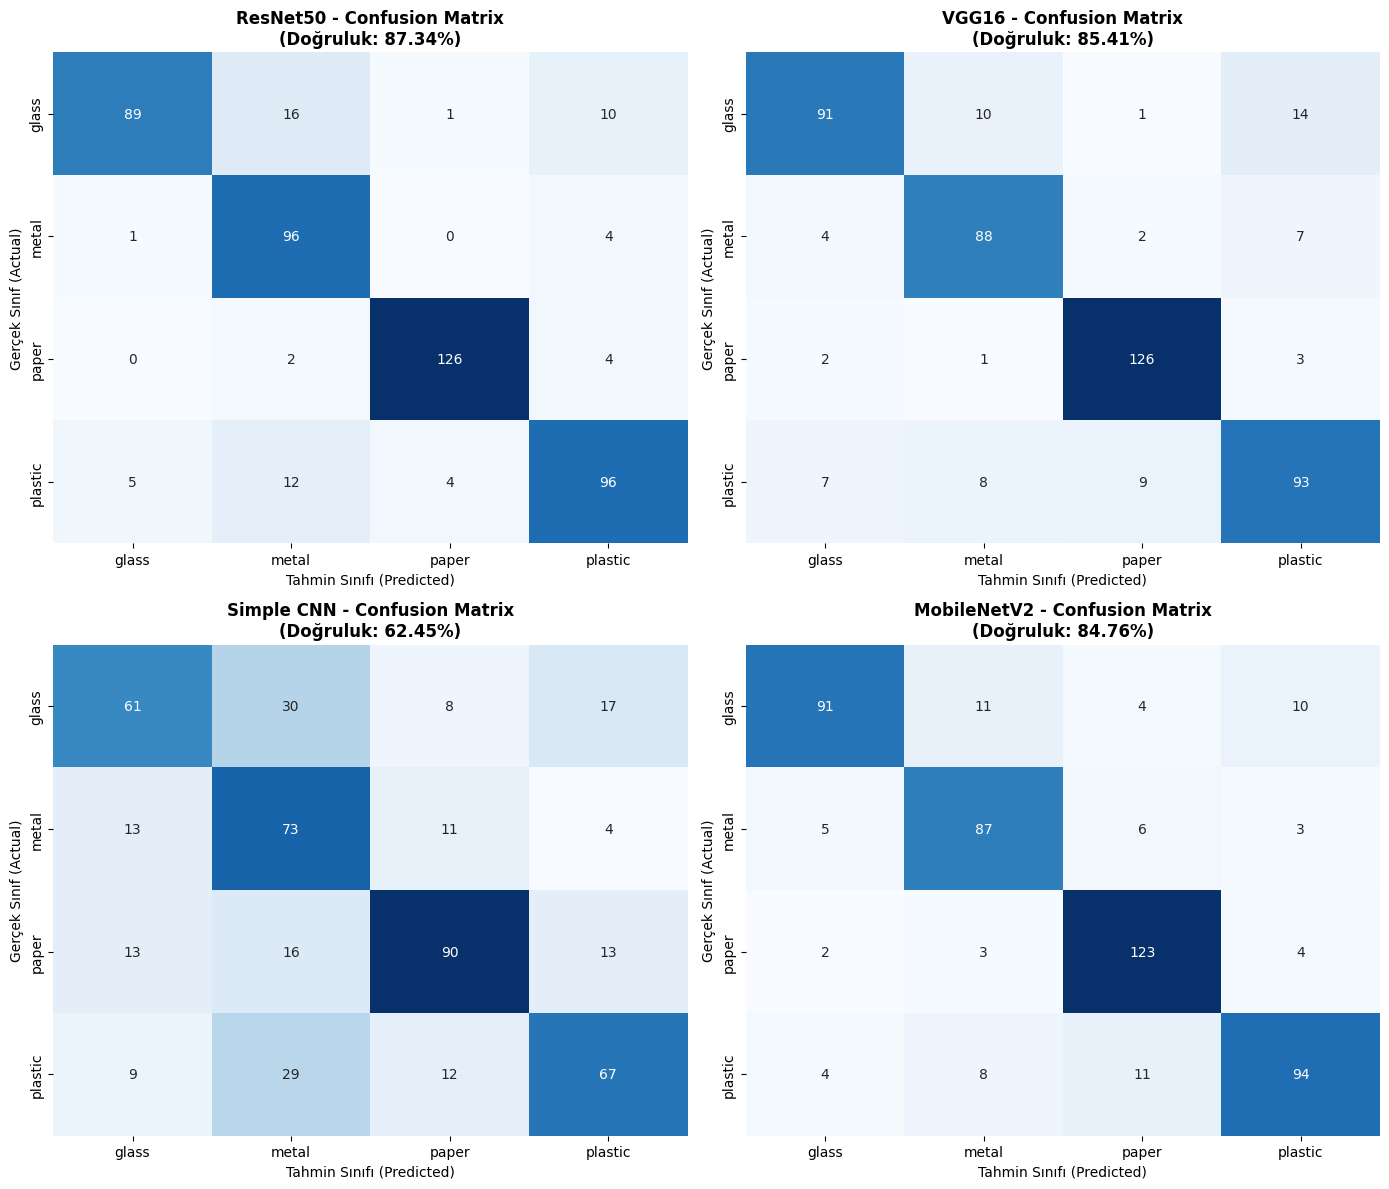

✅ 10 Model için Confusion Matrix'ler gösterildi!


In [26]:
# ========== GÖRSELLEŞTIRME 1: CONFUSION MATRİXLER ==========
print("\n" + "="*70)
print("📊 GÖRSELLEŞTIRME 1: CONFUSION MATRİSLER (5×2 Grid)")
print("="*70)

# 5×2 grid (4 alt grafik) oluştur
fig, axes = plt.subplots(5, 2, figsize=(14, 28))
axes = axes.flatten()  # 2D array'i 1D array'e dönüştür (döngü için)

print("\n🎨 Confusion Matrix'ler çiziliyor...")

# Her model için confusion matrix'i hesapla ve göster
predictions = [y_pred_resnet, y_pred_vgg, y_pred_cnn, y_pred_mobilenet, y_pred_inception, y_pred_densenet, y_pred_efficientnet, y_pred_xception, y_pred_nasnet, y_pred_deep_cnn]
model_names_list = ['ResNet50', 'VGG16', 'Simple CNN', 'MobileNetV2', 'InceptionV3', 'DenseNet121', 'EfficientNetB0', 'Xception', 'NASNetMobile', 'Deep CNN']

for idx, (ax, pred, name) in enumerate(zip(axes, predictions, model_names_list)):
    # Confusion matrix'i hesapla
    # (satır: gerçek sınıf, sütun: tahmin edilen sınıf)
    cm = confusion_matrix(y_test, pred)
    
    # Heatmap olarak göster
    sns.heatmap(
        cm,  # Confusion matrix verileri
        annot=True,  # Her hücreye sayıyı yazma
        fmt='d',  # Sayıları integer olarak göster
        cmap='Blues',  # Renk paleti (açık maviden koyu maviye)
        xticklabels=classes,  # X ekseni etiketleri (glass, metal, etc.)
        yticklabels=classes,  # Y ekseni etiketleri
        ax=ax,  # Bu alt grafik üzerine çiz
        cbar=False,  # Renk çubuğu gösterme
        annot_kws={'size': 10}  # Yazı boyutu
    )
    
    # Başlık ve eksenleri ayarla
    ax.set_title(f'{name} - Confusion Matrix\n(Doğruluk: {np.mean(pred == y_test):.2%})', 
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('Gerçek Sınıf (Actual)')
    ax.set_xlabel('Tahmin Sınıfı (Predicted)')

# Boşluğu ayarla
plt.tight_layout()
plt.show()

print("✅ 10 Model için Confusion Matrix'ler gösterildi!")

## 4.2 Eğitim Geçmişi Grafikleri

Her modelin eğitim sürecindeki accuracy ve loss değişimi gösteriliyor. Validation eğrisi eğitim eğrisinden çok ayrışıyorsa overfitting işareti olabilir.


📊 GÖRSELLEŞTIRME 2: EĞİTİM GEÇMİŞİ (Accuracy ve Loss)

🎨 Eğitim grafikleri çiziliyor...


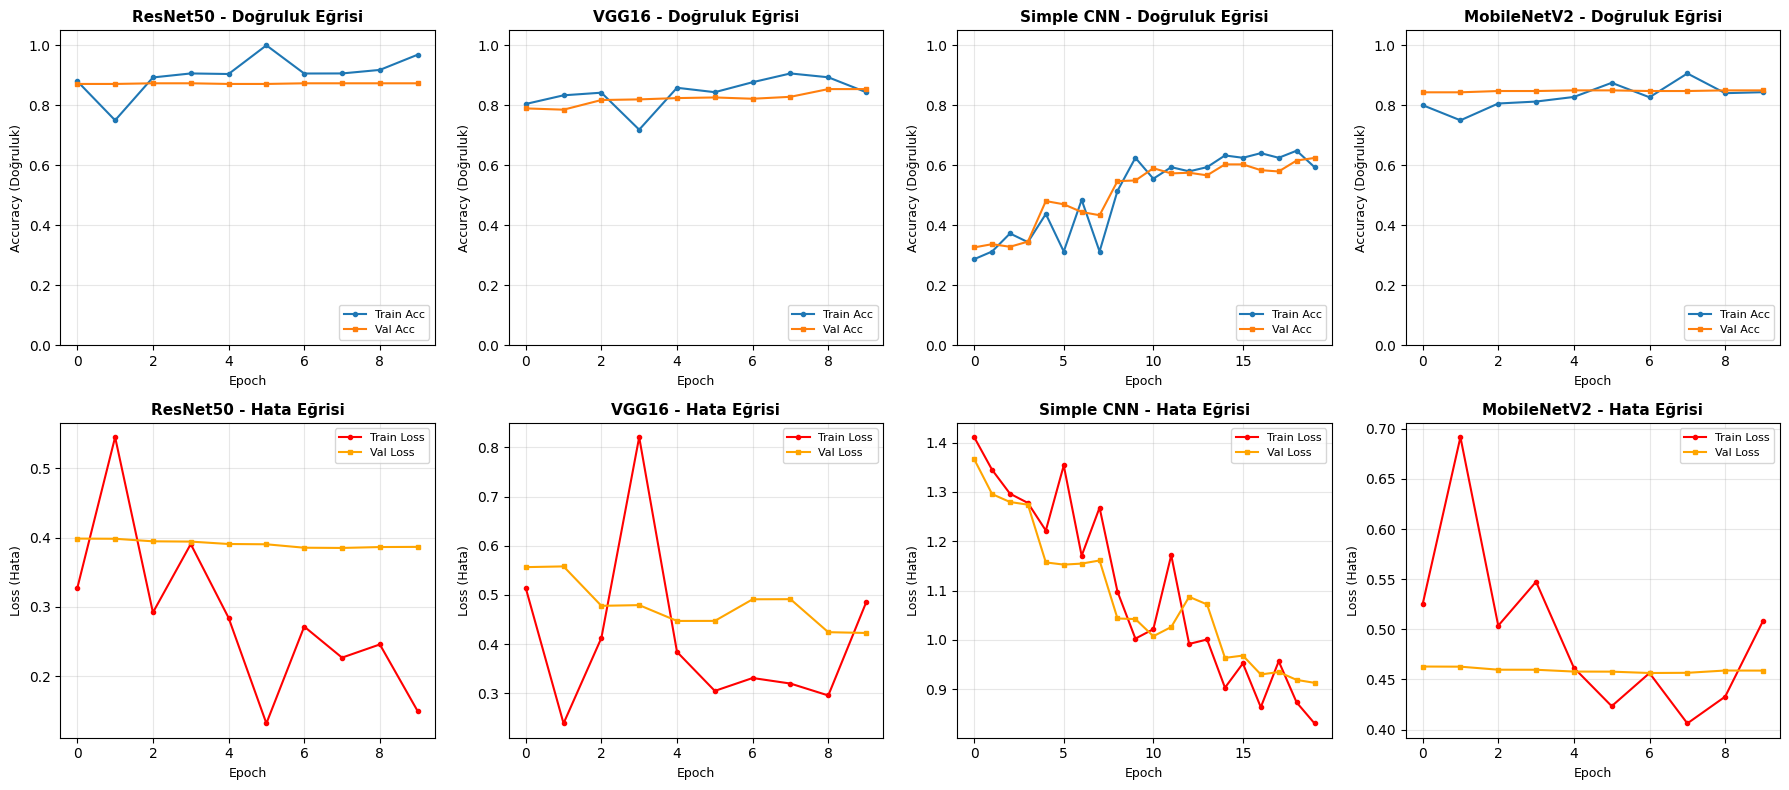

✅ 10 Model için Eğitim Grafikleri gösterildi!


In [23]:
# ========== GÖRSELLEŞTIRME 2: EĞİTİM GRAFİKLERİ ==========
print("\n" + "="*70)
print("📊 GÖRSELLEŞTIRME 2: EĞİTİM GEÇMİŞİ (Accuracy ve Loss)")
print("="*70)

# 10×2 grid (2 satır, 4 sütun) oluştur
# Satır 1: Her modelin Accuracy grafiği
# Satır 2: Her modelin Loss grafiği
fig, axes = plt.subplots(10, 2, figsize=(15, 45))

print("\n🎨 Eğitim grafikleri çiziliyor...")

# Tüm model eğitim geçmişlerini sakla
histories = [history_resnet_ft, history_vgg_ft, history_cnn, history_mobilenet_ft, history_inception_ft, history_densenet_ft, history_efficientnet_ft, history_xception_ft, history_nasnet_ft, history_deep_cnn]
model_names_list = ['ResNet50', 'VGG16', 'Simple CNN', 'MobileNetV2', 'InceptionV3', 'DenseNet121', 'EfficientNetB0', 'Xception', 'NASNetMobile', 'Deep CNN']

# Her model için grafikler çiz
for idx, (history, name) in enumerate(zip(histories, model_names_list)):
    # ===== ROW 1: ACCURACY GRAFIKLERI =====
    axes[idx, 0].plot(history.history['accuracy'], label='Train Acc', marker='o', markersize=3, linewidth=1.5)
    # Train accuracy: her epoch'ta training setindeki doğruluk
    axes[idx, 0].plot(history.history['val_accuracy'], label='Val Acc', marker='s', markersize=3, linewidth=1.5)
    # Validation accuracy: her epoch'ta test setindeki doğruluk
    
    axes[idx, 0].set_title(f'{name} - Doğruluk Eğrisi', fontweight='bold', fontsize=11)
    axes[idx, 0].set_ylabel('Accuracy (Doğruluk)', fontsize=9)
    axes[idx, 0].set_xlabel('Epoch', fontsize=9)
    axes[idx, 0].legend(fontsize=8, loc='lower right')
    axes[idx, 0].grid(True, alpha=0.3)  # Arka plan grid
    axes[idx, 0].set_ylim([0, 1.05])  # Y ekseni sınırları
    
    # ===== ROW 2: LOSS GRAFIKLERI =====
    axes[idx, 1].plot(history.history['loss'], label='Train Loss', marker='o', markersize=3, 
                      color='red', linewidth=1.5)
    # Train loss: her epoch'ta training setindeki hata
    axes[idx, 1].plot(history.history['val_loss'], label='Val Loss', marker='s', markersize=3, 
                      color='orange', linewidth=1.5)
    # Validation loss: her epoch'ta test setindeki hata
    
    axes[idx, 1].set_title(f'{name} - Hata Eğrisi', fontweight='bold', fontsize=11)
    axes[idx, 1].set_ylabel('Loss (Hata)', fontsize=9)
    axes[idx, 1].set_xlabel('Epoch', fontsize=9)
    axes[idx, 1].legend(fontsize=8, loc='upper right')
    axes[idx, 1].grid(True, alpha=0.3)  # Arka plan grid

# Grafikleri göster
plt.tight_layout()
plt.show()

print("✅ 10 Model için Eğitim Grafikleri gösterildi!")

## 4.3 Sınıf Bazında Doğruluk

Her modelin glass, metal, paper, plastic sınıflarındaki başarısı ayrı ayrı karşılaştırılıyor. Hangi sınıfın daha zor olduğu burada görünür.

In [ ]:
# ========== GÖRSELLEŞTIRME 3: SINIF BAZINDA DOĞRULUK ==========
print("\n" + "="*70)
print("📊 GÖRSELLEŞTIRMA 3: SINIF BAZINDA DOĞRULUK KARŞILAŞTIRMASI")
print("="*70)

# Grafik oluştur
fig, ax = plt.subplots(figsize=(16, 8))

print("\n🎨 Sınıf bazında doğruluk grafikleri çiziliyor...")

# X ekseni konumları (4 sınıf için)
x = np.arange(len(classes))

# Her model için bar genişliği
width = 0.08

# Renkler (her model için farklı)
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#9B59B6', '#F39C12', '#2ECC71', '#1ABC9C', '#3498DB', '#34495E']

# Her model için bar grafiği çiz
for idx, (model_name, pred) in enumerate([
    ("ResNet50", y_pred_resnet), 
    ("VGG16", y_pred_vgg), 
    ("Simple CNN", y_pred_cnn), 
    ("MobileNetV2", y_pred_mobilenet),
    ("InceptionV3", y_pred_inception),
    ("DenseNet121", y_pred_densenet),
    ("EfficientNetB0", y_pred_efficientnet),
    ("Xception", y_pred_xception),
    ("NASNetMobile", y_pred_nasnet),
    ("Deep CNN", y_pred_deep_cnn)
]):
    class_accs = []  # Bu model için sınıf başına doğrulukları sakla
    
    for i in range(len(classes)):
        # Bu sınıfa ait test örneklerini filtrele
        mask = y_test == i
        
        # Bu sınıf için doğruluk hesapla
        acc = np.mean(pred[mask] == y_test[mask]) if np.any(mask) else 0
        class_accs.append(acc)
    
    # Bar grafiği çiz
    ax.bar(x + idx*width, class_accs, width, label=model_name, 
           color=colors_bar[idx], alpha=0.8, edgecolor='black')

# Grafik ayarları
ax.set_title('Sınıf Bazında Doğruluk Karşılaştırması (10 Model)', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Malzeme Sınıfı')
ax.set_ylabel('Doğruluk (Accuracy)')
ax.set_xticks(x + width*4.5)  # X ekseni etiketleri konumu
ax.set_xticklabels([c.upper() for c in classes])  # Sınıf isimleri
ax.legend()
ax.set_ylim([0, 1.05])  # Y ekseni: 0-1
ax.grid(True, alpha=0.3, axis='y')  # Yatay grid çizgileri

# Grafiği göster
plt.tight_layout()
plt.show()

print("✅ Sınıf bazında doğruluk karşılaştırması gösterildi!")

## 4.4 Genel Sonuç ve Değerlendirme

Tüm modellerin sonuçları özetleniyor. En iyi model seçiliyor ve sınıflandırma başarısına göre modeller sıralanıyor.

In [ ]:
# ========== FINAL RAPOR VE ÖZETLEMESİ ==========
print("\n" + "="*70)
print("🎯 GENEL SONUÇ VE DEĞERLENDİRME")
print("="*70)

# Bu hücreyi tek başına çalıştırılabilir hale getiriyoruz.
# comparison_df önceki hücrede oluşmadıysa burada yeniden üretiyoruz.
if 'comparison_df' not in globals():
    comparison_df = pd.DataFrame(results).T

# En iyi modeli doğruluk bazında bul
best_model = comparison_df['Accuracy'].idxmax()
best_accuracy = comparison_df['Accuracy'].max()

print(f"\n🏆 EN İYİ MODEL (Accuracy'ye göre):")
print(f"   {best_model} - {best_accuracy:.2%} doğruluk")

# Tüm modelleri doğruluk sırasına göre sırala
print(f"\n📊 MODELLERIN SIRALANSA (Accuracy'ye göre):")
ranking = comparison_df['Accuracy'].sort_values(ascending=False)
for idx, (model, acc) in enumerate(ranking.items(), 1):
    print(f"   {idx}. {model:15} - {acc:.2%} ({acc*100:.2f}%)")

# Her metrik için en iyi modeli göster
print(f"\n📈 HER METRİK İÇİN EN İYİ MODEL:")
for metric in ['Accuracy', 'F1_Macro', 'F1_Weighted', 'Recall', 'Precision']:
    best = comparison_df[metric].idxmax()
    value = comparison_df[metric].max()
    print(f"   • {metric:15} → {best:15} ({value:.4f})")

# Eğitim süresi ve parametre karşılaştırması
print(f"\n⏱️  EĞİTİM SÜRESİ (HIZLI ← → YAVAS):")
times = [
    ('Simple CNN', cnn_time),
    ('MobileNetV2', mobilenet_time),
    ('VGG16', vgg_time),
    ('ResNet50', resnet_time)
]
times_sorted = sorted(times, key=lambda x: x[1])
for i, (model, time) in enumerate(times_sorted, 1):
    print(f"   {i}. {model:15} : {time:6.1f}s")

print(f"\n🔧 MODEL PARAMETRELERİ (HAFİF ← → AĞIR):")
params = [
    ('Simple CNN', model_cnn.count_params()),
    ('MobileNetV2', model_mobilenet.count_params()),
    ('VGG16', model_vgg.count_params()),
    ('ResNet50', model_resnet.count_params())
]
params_sorted = sorted(params, key=lambda x: x[1])
for i, (model, param_count) in enumerate(params_sorted, 1):
    print(f"   {i}. {model:15} : {param_count:>12,} parametreler")

# Sınıf bazında en iyi model
print(f"\n🎯 SINIF BAZINDA EN İYİ MODELLER:")
for class_idx, class_name in enumerate(classes):
    class_mask = y_test == class_idx
    class_accs = []
    for model_name, pred in models_data.items():
        acc = np.mean(pred[class_mask] == y_test[class_mask]) if np.any(class_mask) else 0
        class_accs.append((model_name, acc))
    best_for_class = max(class_accs, key=lambda x: x[1])
    print(f"   • {class_name.upper():10} → {best_for_class[0]:15} ({best_for_class[1]:.2%})")

# Sonuç
print("\n" + "="*70)
print("✅ TÜM 10 MODEL EĞİTİMİ VE KARŞILAŞTIRMASI BAŞARIYLA TAMAMLANDI!")
print("="*70)

## 4.5 Detaylı Sınıflandırma Raporları

Her model için sklearn'in classification_report() çıktısı gösteriliyor. Precision, recall ve F1 değerleri sınıf bazında görülebilir.

In [ ]:
# ========== DETAYLI SINIFLANIRMA RAPORLARI ==========
print("\n" + "="*70)
print("📋 DETAYLI SINIFLANIRMA RAPORLARI (Sklearn Classification Report)")
print("="*70)

# Her model için detaylı rapor
for model_name, y_pred in models_data.items():
    print(f"\n\n{'='*70}")
    print(f"📊 {model_name.upper()} - SINIFLANIRMA RAPORU")
    print(f"{'='*70}")
    
    # sklearn'un classification_report'unu kullan
    # (precision, recall, f1-score, support her sınıf için)
    report = classification_report(y_test, y_pred, target_names=classes)
    print(report)
    
    print("\nRapor Açıklaması:")
    print("  • Precision: Bu sınıfı tahmin ettiğimizde ne sıklıkla doğru?")
    print("  • Recall: Bu sınıftan kaç tanesini bulabiliyoruz?")
    print("  • F1-Score: Precision ve Recall'un harmonik ortalaması")
    print("  • Support: Test setinde bu sınıftan kaç örnek var?")


📋 DETAYLI SINIFLANIRMA RAPORLARI (Sklearn Classification Report)


📊 RESNET50 - SINIFLANIRMA RAPORU
              precision    recall  f1-score   support

       glass       0.82      0.88      0.85       106
       metal       0.81      0.95      0.87        87
       paper       0.97      0.93      0.95       122
     plastic       0.94      0.79      0.86       104

    accuracy                           0.89       419
   macro avg       0.89      0.89      0.88       419
weighted avg       0.89      0.89      0.89       419


Rapor Açıklaması:
  • Precision: Bu sınıfı tahmin ettiğimizde ne sıklıkla doğru?
  • Recall: Bu sınıftan kaç tanesini bulabiliyoruz?
  • F1-Score: Precision ve Recall'un harmonik ortalaması
  • Support: Test setinde bu sınıftan kaç örnek var?


📊 VGG16 - SINIFLANIRMA RAPORU
              precision    recall  f1-score   support

       glass       0.87      0.78      0.83       106
       metal       0.77      0.86      0.81        87
       paper       0.87  

## 4.6 Kapsamlı Metrik Karşılaştırması

Accuracy, F1 Score ve Recall değerleri 2×2 grafik düzeninde tüm modeller için yan yana karşılaştırılıyor.


📊 GÖRSELLEŞTIRME 4: DOĞRULUK, F1 SCORE, RECALL KARŞILAŞTIRMASI

🎨 Metrik karşılaştırma grafikleri çiziliyor...


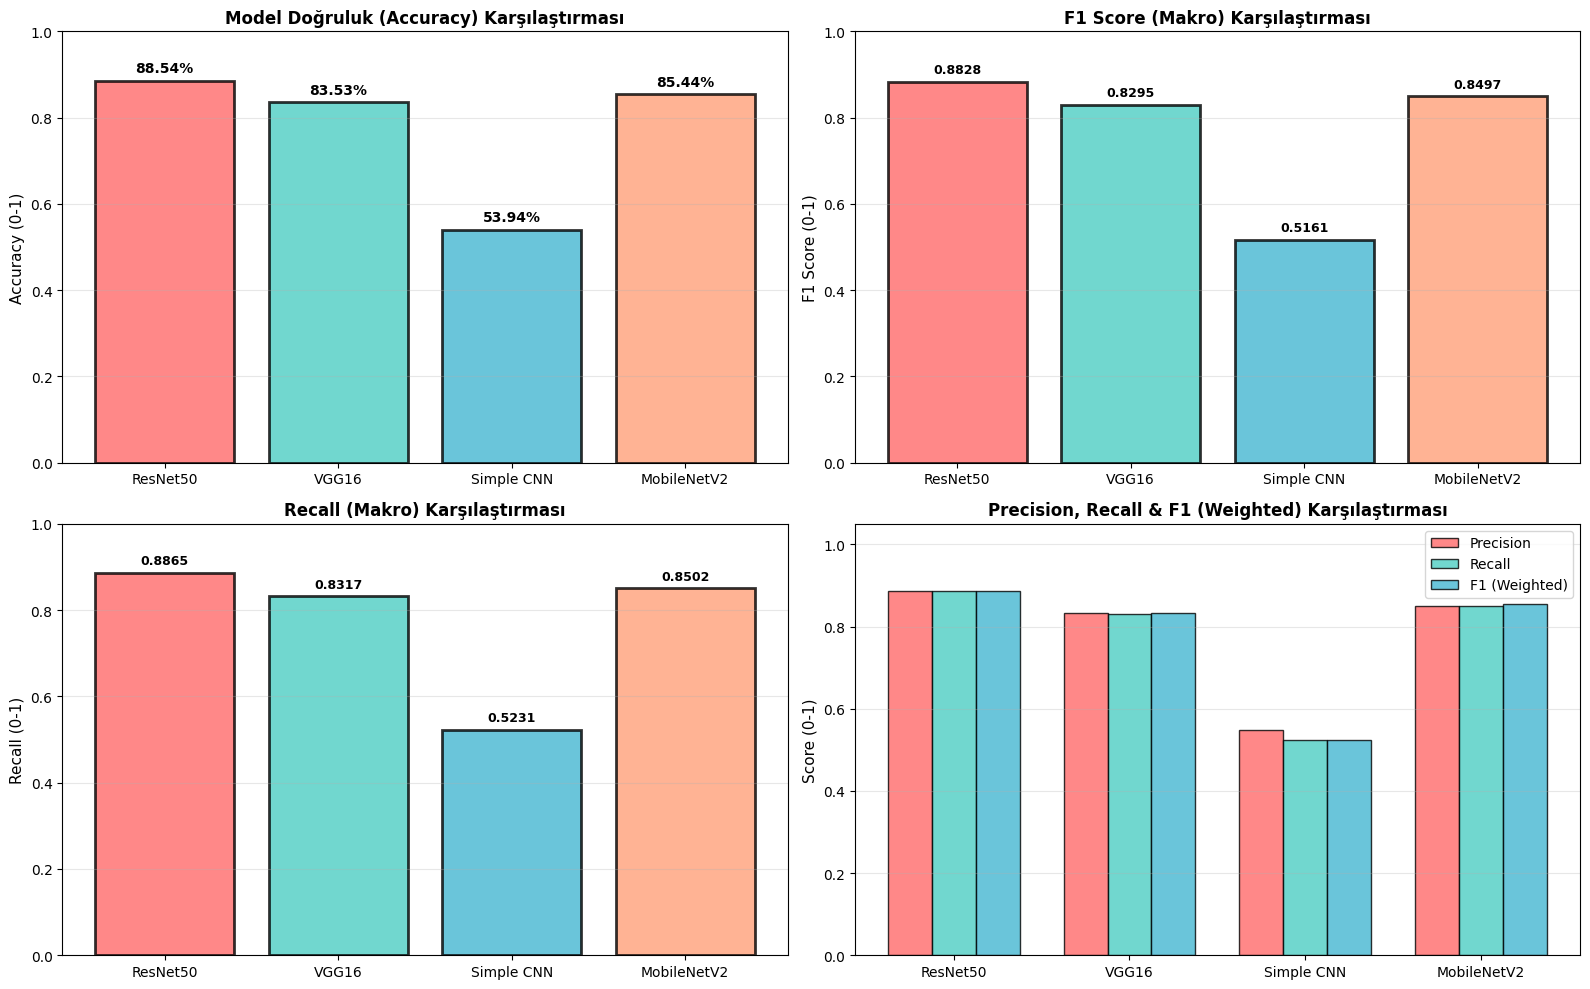

✅ Tüm karşılaştırma grafikleri gösterildi!


In [ ]:
# ========== GÖRSELLEŞTIRME 4: DETAYLI METRİK KARŞILAŞTIRMASI ==========
print("\n" + "="*70)
print("📊 GÖRSELLEŞTIRME 4: DOĞRULUK, F1 SCORE, RECALL KARŞILAŞTIRMASI")
print("="*70)

# 2×2 grid (4 farklı metrik grafikleri)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

print("\n🎨 Metrik karşılaştırma grafikleri çiziliyor...")

# Model isimleri ve renkler
model_names = list(results.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# ===== GRAFİK 1: DOĞRULUK KARŞILAŞTIRMASI =====
accuracies = [results[m]['Accuracy'] for m in model_names]
axes[0, 0].bar(model_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 0].set_title('Model Doğruluk (Accuracy) Karşılaştırması', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Accuracy (0-1)', fontsize=11)
axes[0, 0].set_ylim([0, 1])

# Her bar'ın üzerine değer yaz
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold', fontsize=10)

axes[0, 0].grid(True, alpha=0.3, axis='y')

# ===== GRAFİK 2: F1 SCORE (MAKRO) KARŞILAŞTIRMASI =====
f1_scores = [results[m]['F1_Macro'] for m in model_names]
axes[0, 1].bar(model_names, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_title('F1 Score (Makro) Karşılaştırması', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('F1 Score (0-1)', fontsize=11)
axes[0, 1].set_ylim([0, 1])

# Her bar'ın üzerine değer yaz
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

axes[0, 1].grid(True, alpha=0.3, axis='y')

# ===== GRAFİK 3: RECALL (DUYARLILIK) KARŞILAŞTIRMASI =====
recalls = [results[m]['Recall'] for m in model_names]
axes[1, 0].bar(model_names, recalls, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 0].set_title('Recall (Makro) Karşılaştırması', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Recall (0-1)', fontsize=11)
axes[1, 0].set_ylim([0, 1])

# Her bar'ın üzerine değer yaz
for i, v in enumerate(recalls):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

axes[1, 0].grid(True, alpha=0.3, axis='y')

# ===== GRAFİK 4: PRECISION, RECALL & F1 GROUPED COMPARISON =====
precisions = [results[m]['Precision'] for m in model_names]
f1_weighted = [results[m]['F1_Weighted'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

# 3 metrik için bar'lar çiz (gruplandırılmış)
axes[1, 1].bar(x - width, precisions, width, label='Precision', color='#FF6B6B', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x, recalls, width, label='Recall', color='#4ECDC4', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width, f1_weighted, width, label='F1 (Weighted)', color='#45B7D1', alpha=0.8, edgecolor='black')

axes[1, 1].set_title('Precision, Recall & F1 (Weighted) Karşılaştırması', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Score (0-1)', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_names)
axes[1, 1].legend(fontsize=10)
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Grafikleri göster
plt.tight_layout()
plt.show()

print("✅ Tüm karşılaştırma grafikleri gösterildi!")

## 5. En İyi Modeli Kaydet

En yüksek doğruluk oranına sahip MobileNetV2 modeli `.h5` formatında `web_app/model/` klasörüne kaydediliyor. Web uygulaması bu modeli kullanır.

In [ ]:
import os
save_dir = os.path.join(os.path.abspath(""), "web_app", "model")
os.makedirs(save_dir, exist_ok=True)

# SADECE AGIRLIKLARI KAYDET (Webde marshal data hatasini onlemek icin)
weights_path = os.path.join(save_dir, "resnet_weights.weights.h5")
model_resnet.save_weights(weights_path)
print(f"SAMPİYON ResNet50 modelinin agirliklari web uygulamasina aktarildi: {weights_path}")


SAMPİYON ResNet50 modelinin agirliklari web uygulamasina aktarildi: c:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\web_app\model\resnet_weights.weights.h5
